EXPERIMENT 08 - TASK 02
ANN on Sonar Dataset
Name    : R. Karthik
Roll No : 25EU02904

Dataset Shape:
(208, 61)

ANN Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)


Training completed.

Test Accuracy: 90.48%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89        20
           1       0.88      0.95      0.91        22

    accuracy                           0.90        42
   macro avg       0.91      0.90      0.90        42
weighted avg       0.91      0.90      0.90        42


Confusion Matrix:
[[17  3]
 [ 1 21]]


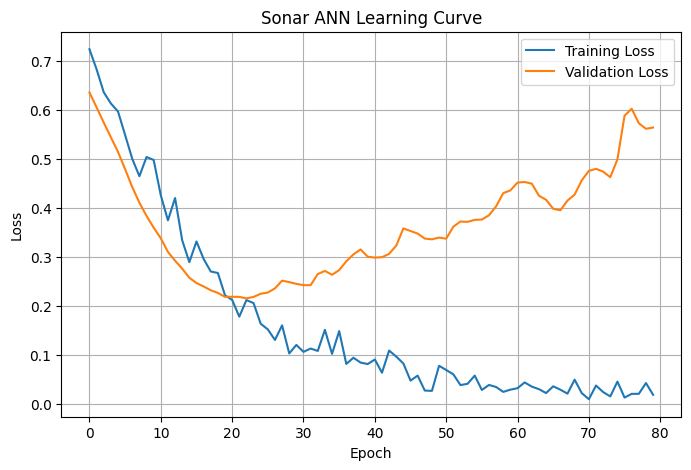

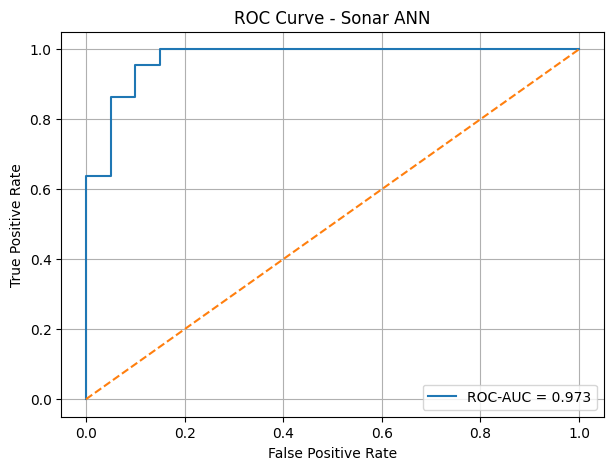


ROC-AUC Score: 0.9727

TASK 02 COMPLETED SUCCESSFULLY
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 08 - TASK 02
# ANN Training and Learning Behaviour
# Sonar Dataset
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("=" * 60)
print("EXPERIMENT 08 - TASK 02")
print("ANN on Sonar Dataset")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load Sonar Dataset
# ------------------------------------------------------------

url = (
    "https://raw.githubusercontent.com/"
    "jbrownlee/Datasets/master/sonar.csv"
)

feature_names = [
    f"Feature_{i}"
    for i in range(1, 61)
]

columns = feature_names + ["Target"]

df = pd.read_csv(
    url,
    header=None,
    names=columns
)

print("\nDataset Shape:")
print(df.shape)

# ------------------------------------------------------------
# 2. Encode Target
# M = Mine = 1
# R = Rock = 0
# ------------------------------------------------------------

df["Target"] = df["Target"].map({
    "M": 1,
    "R": 0
})

X = df[feature_names]
y = df["Target"]

# ------------------------------------------------------------
# 3. Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# 4. Feature Scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

# ------------------------------------------------------------
# 5. Build Deep ANN
# ------------------------------------------------------------

ann = Sequential([
    Dense(
        64,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

# ------------------------------------------------------------
# 6. Compile
# ------------------------------------------------------------

ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nANN Architecture:")
ann.summary()

# ------------------------------------------------------------
# 7. Train
# ------------------------------------------------------------

history = ann.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=80,
    batch_size=16,
    verbose=0
)

print("\nTraining completed.")

# ------------------------------------------------------------
# 8. Evaluate
# ------------------------------------------------------------

loss, accuracy = ann.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    f"\nTest Accuracy: "
    f"{accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# 9. Predictions
# ------------------------------------------------------------

probabilities = ann.predict(
    X_test,
    verbose=0
).ravel()

predictions = (
    probabilities >= 0.5
).astype(int)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        predictions
    )
)

# ------------------------------------------------------------
# 10. Learning Curves
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Sonar ANN Learning Curve"
)

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 11. ROC Curve
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Sonar ANN"
)

plt.legend()
plt.grid(True)

plt.show()

print(
    f"\nROC-AUC Score: {roc_auc:.4f}"
)

# ------------------------------------------------------------
# Conclusion
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TASK 02 COMPLETED SUCCESSFULLY")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)